**Set environment**

In [1]:
suppressMessages(suppressWarnings(source("../run_config_project.R")))
suppressMessages(suppressWarnings(library("SHAPforxgboost")))
suppressMessages(suppressWarnings(library("data.table")))
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319 
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo 
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work 
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data 

You are working with      IGVF BlueSTARR 
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR 
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results 
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts 
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data 
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks 
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs 
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log 
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references 



## Import data

**File existence**

In [2]:
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "*XY_loss_flip*"
txt_fglob = file.path(txt_fdiry, txt_fname)

vec = Sys.glob(txt_fglob)
vec = basename(vec)
for (txt in vec){cat(txt, "\n")}

variant_closed_gof_bluestarr_flankL35R70_pilot_XY_loss_flip.tsv 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_loss_flip_xgb_model.rds 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_loss_flip_xgb_shap.rds 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_loss_flip_xgb_shap.tsv 


**Import table**

In [3]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_loss_flip_xgb_shap.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_xgb_loss_shap = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 65955978        6


ID,variable,value,rfvalue,stdfvalue,mean_value
1,AC0615:ZNF:C2H2_ZF,0.2819129,11.18755,0.9376569,0.0010882
2,AC0615:ZNF:C2H2_ZF,0.3145811,11.18755,0.9376567,0.0010882
3,AC0615:ZNF:C2H2_ZF,0.2958749,11.18755,0.9376569,0.0010882


## Summarise SHAP per motif (gain model)

- `mean_shap_nz > 0` -> when this motif is gained, it on average pushes Δ up -> activator-like.
- `cor_gain_shap > 0` -> stronger motif gain -> larger positive contribution.
- `frac_nonzero` tells you how often the motif gain even happens.

In [4]:
fun_cor_safe = function(x, y, min_n = 10) {
    x = x[is.finite(x)]
    y = y[is.finite(y)]
    
    if (length(x) <= min_n){ return(NA_real_) }
    if (sd(x) == 0 || sd(y) == 0){ return(NA_real_) }

    res = cor(x, y, use = "complete.obs")
    return(res)
}

In [5]:
dat = dat_xgb_loss_shap
dat = dat %>% 
    dplyr::mutate(variable = as.character(variable)) %>%
    dplyr::group_by(variable) %>%
    dplyr::summarise(
        n            = n(),
        n_nonzero    = sum(rfvalue > 0),
        frac_nonzero = n_nonzero / n,
        mean_shap_nz = ifelse(
            n_nonzero > 0,
            mean(value[rfvalue > 0]),
            NA_real_
        ),
        mean_abs_nz  = ifelse(
            n_nonzero > 0,
            mean(abs(value[rfvalue > 0])),
            NA_real_
        ),
        corr_shap_nz = fun_cor_safe(
            rfvalue[rfvalue > 0], 
            value[rfvalue > 0], 
            min_n = 10
        ),
        .groups = "drop"
    )

### assign and show
dat_motif_loss_summary = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 666   7


variable,n,n_nonzero,frac_nonzero,mean_shap_nz,mean_abs_nz,corr_shap_nz
AC0001:DLX/LHX:Homeodomain,99033,350,0.0035342,-0.0002037,0.0002061,-0.1460277
AC0002:EMX/PAX:Homeodomain,99033,525,0.0053013,0.0025865,0.0026414,-0.2545659
AC0003:HOXB/BARHL:Homeodomain,99033,256,0.0025850,0.0000261,0.0000261,0.0244430
AC0004:PAX/LHX:Homeodomain,99033,426,0.0043016,-0.0005980,0.0006037,-0.2588666
AC0005:POU6F/NKX:Homeodomain,99033,468,0.0047257,-0.0003750,0.0003836,-0.4737990
"AC0006:POU3F/POU1F:Homeodomain,POU",99033,616,0.0062201,0.0000401,0.0000432,-0.0623927


```
Pick a "core" set of candidate activators

Filter to motifs that:

Have enough data (n_nonzero large enough).

Have strong effect (mean_abs_nz in top 10% or similar).

Have positive mean_shap_nz and positive cor_gain_shap.
```

In [6]:
### choose a core set based on effect size
dat = dat_motif_loss_summary
vec = dat$mean_abs_nz
vec = vec[!is.na(vec)]
num = quantile(vec, 0.9)
num_threshold_abs = num
print(num)

### filter based on teh threshold
dat = dat_motif_loss_summary
dat = dat %>%
    dplyr::filter(
        n_nonzero   >= 100,              # enough events
        mean_abs_nz >= num_threshold_abs # top 10% by importance
    )
dat_motif_loss_filter = dat
print(dim(dat))

         90% 
0.0006163706 
[1] 65  7


In [7]:
### within this core, get strongest activator-like motifs
dat = dat_motif_loss_filter
dat = dat %>%
    dplyr::filter(
        mean_shap_nz > 0, # pushes Δ up
        corr_shap_nz > 0  # more gain → larger Δ
    ) %>%
    dplyr::arrange(desc(mean_shap_nz))

dat_motif_repressor = dat
print(dim(dat))
fun_display_table(head(dat, 20))

[1] 46  7


variable,n,n_nonzero,frac_nonzero,mean_shap_nz,mean_abs_nz,corr_shap_nz
AC0615:ZNF:C2H2_ZF,99033,3293,0.0332515,0.0185503,0.0186303,0.4628799
AC0613:ZNF:C2H2_ZF,99033,1595,0.0161057,0.0095472,0.0096139,0.5178587
AC0241:GFI/GFI1B:C2H2_ZF,99033,1888,0.0190644,0.0046111,0.0046242,0.3098360
AC0127:TCF7L/LEF:Sox,99033,1051,0.0106126,0.0044630,0.0045186,0.4827229
AC0256:MAFF/MAF:bZIP,99033,1727,0.0174386,0.0042747,0.0042855,0.3078524
AC0009:DUXA/DUX:Homeodomain,99033,597,0.0060283,0.0032940,0.0032968,0.0691091
AC0097:HOXB/PBX:Homeodomain,99033,427,0.0043117,0.0025720,0.0025746,0.2699292
AC0126:NR1I/VDR:Nuclear_receptor,99033,829,0.0083709,0.0025114,0.0025331,0.4932056
AC0401:ZNF:C2H2_ZF,99033,1194,0.0120566,0.0022973,0.0023136,0.2633366
AC0671:IRF:IRF,99033,1001,0.0101077,0.0022243,0.0022290,0.3999046


In [9]:
### within this core, get strongest activator-like motifs
dat = dat_motif_loss_filter
dat = dat %>%
    dplyr::filter(
        mean_shap_nz > quantile(mean_shap_nz, 0.9, na.rm = TRUE),
        corr_shap_nz > 0.3 
    ) %>%
    dplyr::arrange(desc(mean_shap_nz))

dat_motif_repressor_strict = dat
print(dim(dat))
fun_display_table(head(dat, 20))

[1] 5 7


variable,n,n_nonzero,frac_nonzero,mean_shap_nz,mean_abs_nz,corr_shap_nz
AC0615:ZNF:C2H2_ZF,99033,3293,0.0332515,0.0185503,0.0186303,0.4628799
AC0613:ZNF:C2H2_ZF,99033,1595,0.0161057,0.0095472,0.0096139,0.5178587
AC0241:GFI/GFI1B:C2H2_ZF,99033,1888,0.0190644,0.0046111,0.0046242,0.3098360
AC0127:TCF7L/LEF:Sox,99033,1051,0.0106126,0.0044630,0.0045186,0.4827229
AC0256:MAFF/MAF:bZIP,99033,1727,0.0174386,0.0042747,0.0042855,0.3078524


This table is a very natural “Top activator candidates (gain model)” table for Bill / committee:

variable: motif name (you may want to map AC IDs → TF family / JASPAR ID later).

mean_shap_nz: average effect on Δ when motif gain is present.

mean_abs_nz: importance.

frac_nonzero: how prevalent the gain is across variants.

cor_gain_shap: monotonicity of the effect.

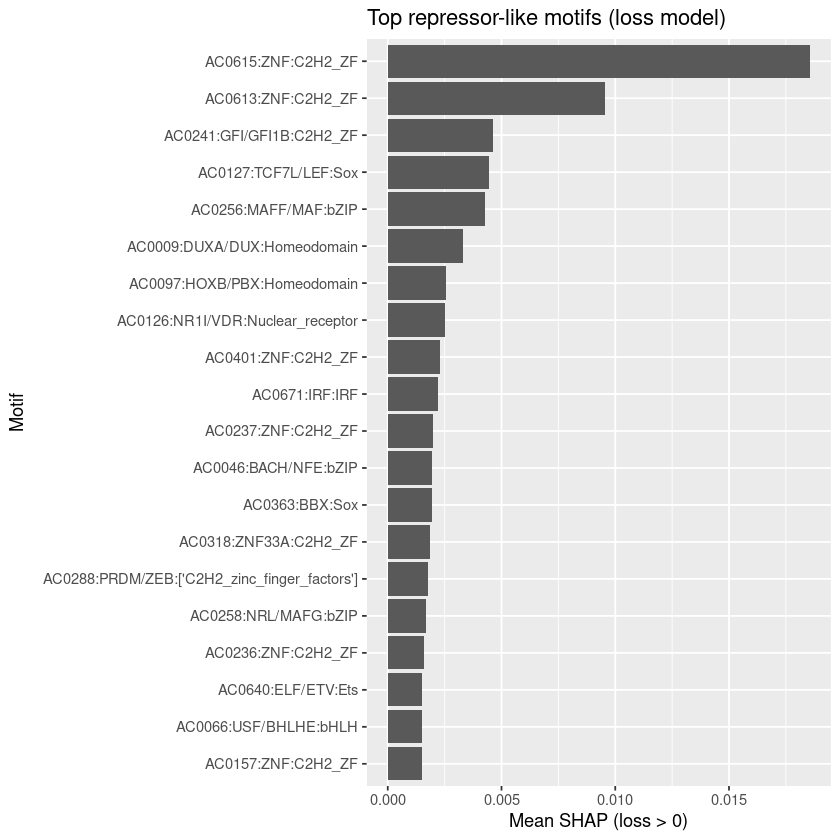

In [14]:
top_act <- dat_motif_repressor %>%
  slice_max(order_by = mean_shap_nz, n = 20)

ggplot(top_act,
       aes(x = reorder(variable, mean_shap_nz),
           y = mean_shap_nz)) +
  geom_col() +
  coord_flip() +
  labs(
    x = "Motif",
    y = "Mean SHAP (loss > 0)",
    title = "Top repressor-like motifs (loss model)"
  )

In [16]:
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_motif_repressor.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

dat = dat_motif_repressor
write_tsv(dat, txt_fpath)

## SHAP dependent plot

Summary of what you are doing conceptually

Gain model:

Features = motif gain strength (0 or >0).

Positive SHAP = “gaining this motif pushes Δ up”.

You summarise SHAP across variants to rank motifs whose gain consistently and strongly increases Δ → activator-like motifs.

Next step (later) will be symmetric:

Use the loss-flip model (features = loss magnitude, SHAP > 0 ⇒ destroying that motif increases Δ) to call repressor-like motifs, using the same kind of summary.

In [15]:
head(dat_xgb_loss_shap)

ID,variable,value,rfvalue,stdfvalue,mean_value
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,AC0615:ZNF:C2H2_ZF,0.2819129,11.18755,0.9376569,0.001088178
2,AC0615:ZNF:C2H2_ZF,0.3145811,11.18755,0.9376567,0.001088178
3,AC0615:ZNF:C2H2_ZF,0.2958749,11.18755,0.9376569,0.001088178
4,AC0615:ZNF:C2H2_ZF,0.3108016,11.18755,0.9376569,0.001088178
5,AC0615:ZNF:C2H2_ZF,0.2061844,10.02180,0.8399525,0.001088178
6,AC0615:ZNF:C2H2_ZF,0.2946884,11.18755,0.9376569,0.001088178


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the SHAPforxgboost package.
  Please report the issue at <https://github.com/liuyanguu/SHAPforxgboost/issues>.”
`geom_smooth()` using formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“at  -0.038105”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“radius  0.001452”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“all data on boundary of neighborhood. make span bigger”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.038105”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.038105”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = par

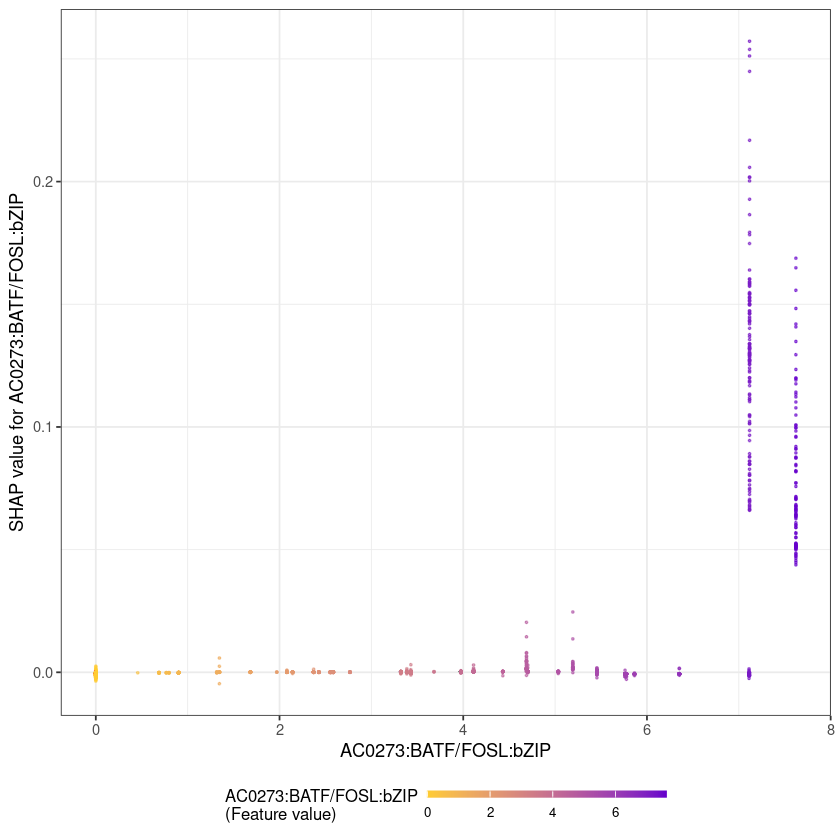

In [24]:
shap.plot.dependence(
    data_long = as.data.table(dat_xgb_gain_shap),
    x = "AC0273:BATF/FOSL:bZIP",
    color_feature = "AC0273:BATF/FOSL:bZIP"
)

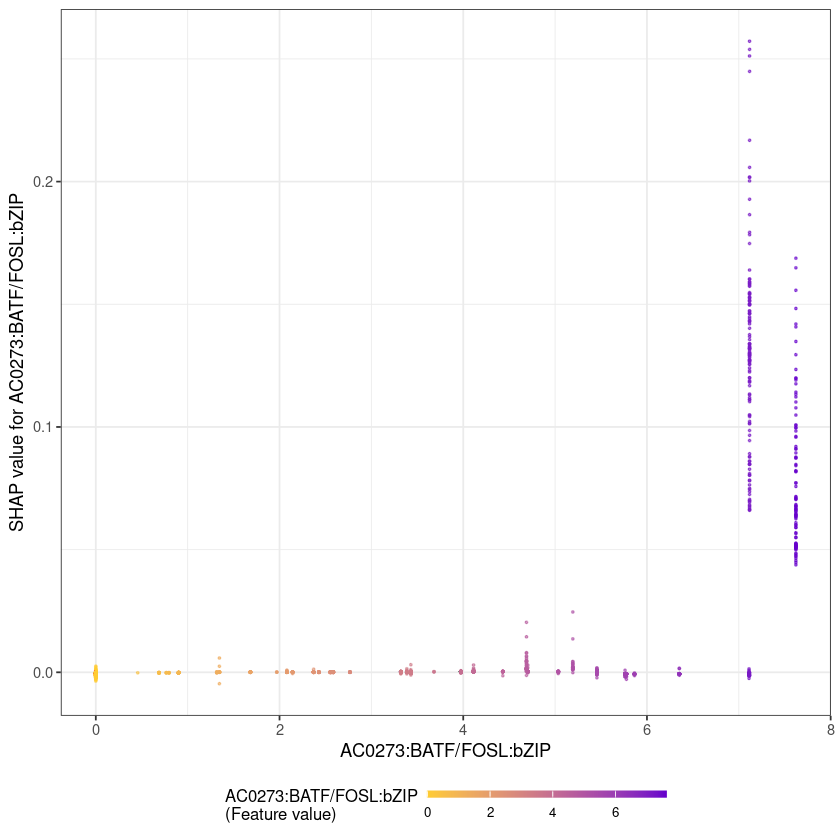

In [25]:
p <- shap.plot.dependence(
  data_long     = as.data.table(dat_xgb_gain_shap),
  x             = "AC0273:BATF/FOSL:bZIP",
  color_feature = "AC0273:BATF/FOSL:bZIP"
)

# Remove smoothing layer if present
p$layers <- p$layers[!vapply(p$layers, function(layer) {
  inherits(layer$geom, "GeomSmooth")
}, logical(1))]

print(p)

In [26]:
class(p)

[1] "ggplot2::ggplot" "ggplot"          "ggplot2::gg"     "S7_object"      
[5] "gg"

In [ ]:
dat = dat_motif_activator
dat = dat %>% 
    tidyr::pivot_wider(
        id_cols   = variable, 
        id_expand = 
        values_from = mean_shap_nz
        